<a href="https://colab.research.google.com/github/vineetsalar88/ResearchPaper2/blob/master/30Dec25EfficientB0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

csv_path ="/content/drive/MyDrive/ResearchData/AnnotatedDataset28Dec25/AnnonatationsCroppedImagesScale0to5.csv"
image_folder = "/content/drive/MyDrive/ResearchData/AnnotatedDataset28Dec25/CroppedImages"   # folder containing images

df = pd.read_csv(csv_path)

# Add full image paths
df['image_path'] = df['image_name'].apply(
    lambda x: os.path.join(image_folder, x)
)
modified_csv_path = "/content/drive/MyDrive/ResearchData/AnnotatedDataset28Dec25/labelsWithPaths.csv"

df.to_csv(modified_csv_path, index=False)

print("✅ Modified CSV saved at:", modified_csv_path)




✅ Modified CSV saved at: /content/drive/MyDrive/ResearchData/AnnotatedDataset28Dec25/labelsWithPaths.csv


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/ResearchData/AnnonatedDataset17Dec25/annotationsResnet.csv")

class_map = {
    "Score 1": 0,
    "Score 2": 1,
    "Score 3": 2,
    "Score 4": 3,
    "Score 5": 4,
    "Score 6": 5,
   }

df["label"] = df["label"].map(class_map)
df.to_csv("/content/drive/MyDrive/ResearchData/AnnonatedDataset17Dec25/annotationsImagenet.csv", index=False)

In [1]:
#Custom Dataset to read images + CSV
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset

class ImageCSVDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx, 0]
        label = int(self.data.iloc[idx, 1])

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


In [4]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torch.utils.data import random_split

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.3, 0.3, 0.3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [7]:

# Load dataset
csv_path = "/content/drive/MyDrive/ResearchData/AnnotatedDataset28Dec25/labelsWithPaths.csv"
image_dir = "/content/drive/MyDrive/ResearchData/AnnotatedDataset28Dec25/CroppedImages"

full_dataset = ImageCSVDataset(csv_path, image_dir, transform=train_transform)

train_size = int(0.7 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size]
)

# IMPORTANT: use val transforms
val_dataset.dataset.transform = val_transform

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)



In [8]:
print("Train dataset size:", len(train_loader.dataset))
print("Number of train batches:", len(train_loader))
print("Validation dataset size:", len(val_loader.dataset))
print("Number of train batches:", len(val_loader))


Train dataset size: 437
Number of train batches: 28
Validation dataset size: 188
Number of train batches: 12


In [11]:
import torch
import torch.nn as nn
import torchvision.models as models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=True)

# Freeze backbone
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier (6 classes)
model.classifier[1] = nn.Linear(1280, 6)

model.to(device)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 124MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3
)


In [12]:
print("Train dataset size:", len(train_loader.dataset))
print("Number of train batches:", len(train_loader))
print("Validation dataset size:", len(val_loader.dataset))
print("Number of train batches:", len(val_loader))


Train dataset size: 437
Number of train batches: 28
Validation dataset size: 188
Number of train batches: 12


| Part               | Status             |
| ------------------ | ------------------ |
| ResNet Conv layers | ❄️ Frozen          |
| BatchNorm          | ❄️ Frozen          |
| FC layer           | 🔥 Trainable       |
| Optimizer          | FC parameters only |


In [14]:
#Loss & optimizer (only classifier trained)
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3
)


In [16]:
import os
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

epochs = 24
checkpoint_path = "/content/drive/MyDrive/Models/30Dec25EfficientB0_checkpoint.pth"

# ======================
# 🔹 LOAD CHECKPOINT
# ======================
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch"]

    train_losses = checkpoint["train_losses"]
    train_accuracies = checkpoint["train_accuracies"]

    print(f"✅ Resuming from epoch {start_epoch}")
else:
    start_epoch = 0
    train_losses = []
    train_accuracies = []
    val_accuracies = []

# ======================
# 🔹 TRAINING LOOP
# ======================
for epoch in range(start_epoch, epochs):

    # -------- TRAIN --------
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0


    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100.0 * train_correct /train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # -------- VALIDATION --------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100.0 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # ======================
    # 🔹 SAVE CHECKPOINT
    # ======================
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "train_losses": train_losses,
        "train_accuracies": train_accuracies
    }, checkpoint_path)


Epoch [1/24] Train Loss: 1.4757 | Train Acc: 37.30% | Val Loss: 1.2933 | Val Acc: 55.32%
Epoch [2/24] Train Loss: 1.1347 | Train Acc: 58.35% | Val Loss: 1.1866 | Val Acc: 56.38%
Epoch [3/24] Train Loss: 0.9748 | Train Acc: 67.51% | Val Loss: 1.0790 | Val Acc: 60.64%
Epoch [4/24] Train Loss: 0.9026 | Train Acc: 66.59% | Val Loss: 1.0486 | Val Acc: 57.98%
Epoch [5/24] Train Loss: 0.8486 | Train Acc: 70.48% | Val Loss: 1.0147 | Val Acc: 59.57%
Epoch [6/24] Train Loss: 0.7644 | Train Acc: 72.54% | Val Loss: 1.0164 | Val Acc: 57.98%
Epoch [7/24] Train Loss: 0.7838 | Train Acc: 71.62% | Val Loss: 0.9860 | Val Acc: 56.38%
Epoch [8/24] Train Loss: 0.7249 | Train Acc: 75.51% | Val Loss: 0.9666 | Val Acc: 59.04%
Epoch [9/24] Train Loss: 0.6908 | Train Acc: 76.43% | Val Loss: 0.9641 | Val Acc: 59.04%
Epoch [10/24] Train Loss: 0.6932 | Train Acc: 76.66% | Val Loss: 0.9664 | Val Acc: 60.64%
Epoch [11/24] Train Loss: 0.6762 | Train Acc: 77.80% | Val Loss: 0.9411 | Val Acc: 63.30%
Epoch [12/24] Train

ValueError: x and y must have same first dimension, but have shapes (24,) and (48,)

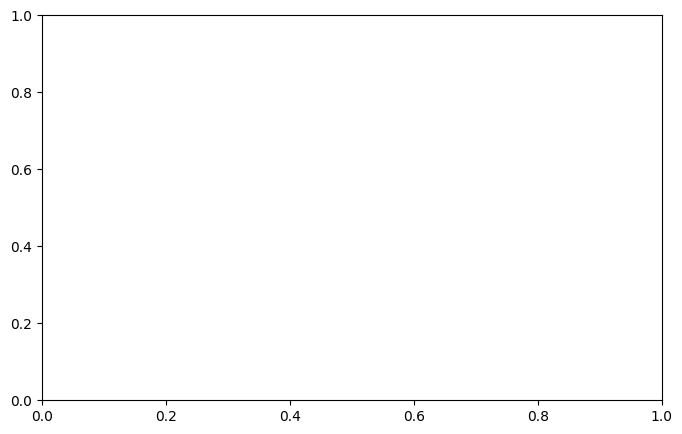

In [17]:
import matplotlib.pyplot as plt

epochs_range = range(1, epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.title("EfficientNet-B0 Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


[[ 0  0  1  0  0  0]
 [ 0  1  2  1  0  0]
 [ 0  3 19  5  5  0]
 [ 0  0  5 25  4  0]
 [ 0  2  3  9 23  1]
 [ 0  1  0  1  6  8]]


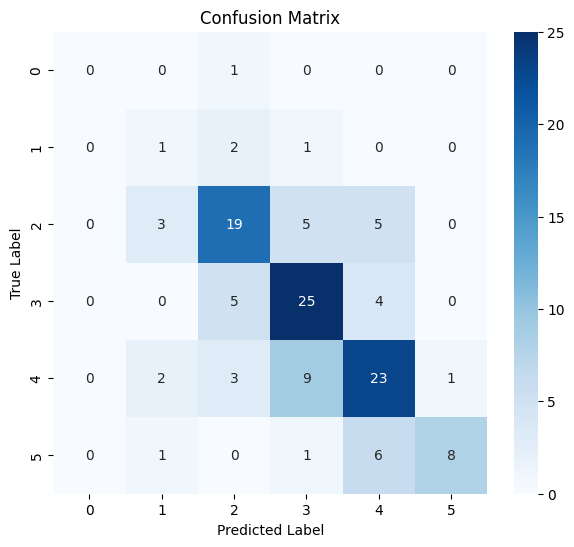

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
cm = confusion_matrix(all_labels, all_preds)
print(cm)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()
